In [1]:
import torch
print(torch.__version__)

2.6.0+cu118


In [12]:
torch.cuda.is_available()

True

In [ ]:
import numpy as np
from scipy.sparse import rand as sprand
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:

#Generate Sparse Ratings Data

n_users = 1000
n_items = 1000
density = 0.01  # 1% of the user-item matrix is filled

ratings = sprand(n_users, n_items, density=density, format="csr")
ratings.data = np.random.randint(1, 6, size=ratings.nnz).astype(np.float64)
ratings = ratings.toarray()

# Get non-zero rating indices
rows, cols = ratings.nonzero()
p = np.random.permutation(len(rows))
rows, cols = rows[p], cols[p]


In [ ]:

class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors=20):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors, sparse=True)
        self.item_factors = nn.Embedding(n_items, n_factors, sparse=True)

    def forward(self, user, item):
        return (self.user_factors(user) * self.item_factors(item)).sum(1)


In [ ]:

model = MatrixFactorization(n_users, n_items, n_factors=20).to(device)
loss_func = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)


In [ ]:

losses = []

for i, (row, col) in enumerate(zip(rows, cols)):
    user = torch.LongTensor([row]).to(device)
    item = torch.LongTensor([col]).to(device)
    rating = torch.FloatTensor([ratings[row, col]]).to(device)

    optimizer.zero_grad()
    prediction = model(user, item)
    loss = loss_func(prediction, rating)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i % 10000 == 0:
        print(f"[{i}/{len(rows)}] Loss: {loss.item():.4f}")


[0/10000] Loss: 0.6262


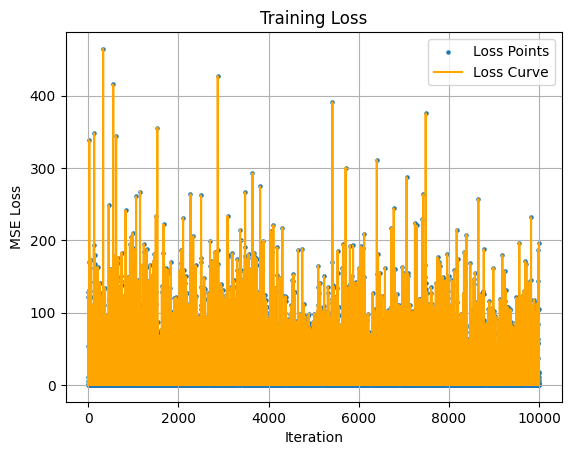

In [24]:
import matplotlib.pyplot as plt

x = list(range(len(losses)))

# Plot scatter points
plt.scatter(x, losses, s=5, label='Loss Points')

# Connect them with a curve
plt.plot(x, losses, color='orange', label='Loss Curve')

plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:


# Example: Predict rating for user 10 on item 20
user_id = 10
item_id = 20

user_tensor = torch.LongTensor([user_id]).to(device)
item_tensor = torch.LongTensor([item_id]).to(device)

pred_rating = model(user_tensor, item_tensor).item()
print(f"Predicted rating by user {user_id} for item {item_id}: {pred_rating:.2f}")


Predicted rating by user 10 for item 20: 2.96


In [20]:
# Recommend top-5 items for a user that they haven't rated yet
user_id = 42
user_tensor = torch.LongTensor([user_id] * n_items).to(device)
item_tensor = torch.LongTensor(range(n_items)).to(device)

# Predict all items for the user
with torch.no_grad():
    predictions = model(user_tensor, item_tensor).cpu().numpy()

# Mask already rated items
rated_items = ratings[user_id].nonzero()[0]
predictions[rated_items] = -1  # Ignore already rated

top_items = predictions.argsort()[-5:][::-1]
print(f"\nTop-5 recommended items for user {user_id}: {top_items}")
print(f"Predicted ratings: {predictions[top_items]}")



Top-5 recommended items for user 42: [886  19  68 921 237]
Predicted ratings: [12.953943  12.457792  12.4112625 12.151732  11.105396 ]
